# Notebook 16 — Empirical GC and TDMI dependence structure

> **Contract.** This notebook investigates lagged dependence among squared USDJPY returns, annualised realised variance, and annualised implied variance. It implements Exercise 1. It does not estimate event weights, create eventless counterfactuals, forecast, use scheduled-event variables, implement Equation (5), or fit non-parametric/Transformer models.

GC is conditional linear predictive content, not structural causality. TDMI is pairwise lagged statistical dependence, not structural causality. History order, an individual distributed-lag coefficient, and a TDMI peak are different statistical objects. Empirical USDJPY data have no simulator-imposed timing, so synthetic +1 timing and prior 1-week-IV findings are not imposed.

## 1. Variables, equations, and units

The candidate realised-variance equation is
$$\widetilde\sigma_t^2=c+\sum_{j=1}^n[a_j\widetilde\sigma_{t-j}^2+b_jr_{t-j}^2+g_j\sigma_{t-j}^2] +u_t^R,$
and the implied-variance equation is
$$\sigma_t^2=c+\sum_{j=1}^m[a_j\sigma_{t-j}^2+b_jr_{t-j}^2+g_j\widetilde\sigma_{t-j}^2] +u_t^I.$

At intraday frequency, rv_within is $\sum_h r_{t,h}^2$, the sum of squared hourly log returns over a complete model day. The primary realised state is $252\sum_h r_{t,h}^2$: variance, rather than volatility, scales linearly with the business-time annualisation factor. The corresponding annualised realised volatility is $\sqrt{252\sum_h r_{t,h}^2}$, not 252 times daily volatility.

The Bloomberg quote in volatility points gives annualised implied volatility $\sigma_t^{imp,ann}=q_t/100$ and annualised implied variance $(q_t/100)^2$, used directly as iv_ann_var. The 252 convention applies only to our realised-variance annualisation and is not a claim that Bloomberg uses 252.

The daily complete-session return is $r_t=\sum_h r_{t,h}$. Its square is $r_t^2=(\sum_h r_{t,h})^2=\sum_h r_{t,h}^2+2\sum_{i<j}r_{t,i}r_{t,j}$, unlike realised variance. Thus offsetting intraday moves can leave a small net return but substantial realised variation. The analysis deliberately keeps all three primary states in levels: no log, difference, winsorisation, standardisation, or silent removal of economically large observations.

## 2. Observable implied variance and chronological discipline

Equation (5) is **not implemented**. The observed rolling Bloomberg USDJPY overnight/1D ATM implied-variance state is an empirical observable predictor; it is not asserted to be mathematically identical to the exact forward-implied-variance object. No volatility-surface interpolation is performed, and Bloomberg quote/fixing time remains unresolved.

The full model-day calendar is split chronologically 60%/20%/20% before any missing-value filtering. Training selects diagnostics, orders, bins, and TDMI peaks; validation evaluates frozen training choices; test evaluates the already frozen specification and never changes orders, transformations, peaks, or retained-driver flags.

The final TDMI inference convention is $I(X_{t-k};Y_t)$ for $k=1,\ldots,20$. X is the explicitly named source and Y the explicitly named target, so positive k always means the source precedes the target by k model days. The opposite direction is tested by swapping source and target: $I(I_{t-k};R_t)$ tests implied variance leading realised variance, whereas $I(R_{t-k};I_t)$ tests realised variance leading implied variance. Thus bidirectional detection uses separate directional source-target tests rather than positive and negative inferential lags on one curve. This keeps the target time index explicit and avoids train/validation/test boundary leakage. A signed convention, if displayed, is visualisation only. Friday-to-Monday remains one model-day lag, and lags are built on the complete ordered calendar before validity masks are applied.

In [1]:

from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "Data"
PROCESSED_DIR = DATA_DIR / "processed"
INPUT_PATH = PROCESSED_DIR / "usdjpy_daily_model_panel.csv"
RUN_ID = pd.Timestamp.now(tz="UTC").isoformat()
MAX_LAG, ALPHA, MIN_STATIONARITY_BLOCK = 20, .05, 252
TDMI_SURROGATES, RANDOM_SEED, PRIMARY_BINS = 1000, 16017, 10
STATES = ["squared_return","realised_variance_ann_252","implied_variance_ann"]
if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Required Notebook 15 export missing: {INPUT_PATH}")

panel=pd.read_csv(INPUT_PATH,parse_dates=["model_day"]).sort_values("model_day").reset_index(drop=True)
assert panel.model_day.is_monotonic_increasing and panel.model_day.is_unique
assert {"rv_eligible","rv_within","iv_ann_var","within_session_log_return","rv_with_closure_gap"}.issubset(panel.columns)
panel["squared_return"]=panel.within_session_log_return**2
panel["realised_variance_ann_252"]=252.0*panel.rv_within
panel["implied_variance_ann"]=panel.iv_ann_var
panel["realised_variance_with_closure_ann_252"]=252.0*panel.rv_with_closure_gap
panel["structure_eligible"]=panel.rv_eligible.fillna(False).astype(bool)&np.isfinite(panel[STATES]).all(axis=1)
assert np.isfinite(panel.loc[panel.structure_eligible,STATES].to_numpy(float)).all()
assert np.allclose(panel.loc[panel.rv_within.notna(),"realised_variance_ann_252"],252*panel.loc[panel.rv_within.notna(),"rv_within"])
assert np.allclose(panel.loc[panel.iv_ann_var.notna(),"implied_variance_ann"],panel.loc[panel.iv_ann_var.notna(),"iv_ann_var"])
assert np.allclose(panel.loc[panel.within_session_log_return.notna(),"squared_return"],panel.loc[panel.within_session_log_return.notna(),"within_session_log_return"]**2)

N=len(panel);train_end=math.floor(.60*N);validation_end=math.floor(.80*N)
panel["sample_split"]=np.select([panel.index<train_end,panel.index<validation_end],["train","validation"],default="test")
for state in STATES+["realised_variance_with_closure_ann_252"]:
    for lag in range(1,MAX_LAG+1):panel[f"{state}_lag{lag}"]=panel[state].shift(lag)
assert MAX_LAG==20 and pd.isna(panel.loc[0,"squared_return_lag1"])
assert panel.loc[1,"squared_return_lag1"]==panel.loc[0,"squared_return"]
assert not any("event" in x.lower() or "forecast" in x.lower() for x in STATES)

coverage=(panel.groupby("sample_split",sort=False).agg(calendar_rows=("model_day","size"),calendar_start=("model_day","min"),calendar_end=("model_day","max"),eligible_rows=("structure_eligible","sum")).reset_index())
eligible_range=(panel.loc[panel.structure_eligible].groupby("sample_split",sort=False).agg(first_eligible_model_day=("model_day","min"),last_eligible_model_day=("model_day","max")).reset_index())
coverage=coverage.merge(eligible_range,on="sample_split",how="left")
definitions=pd.DataFrame([
["squared_return","within_session_log_return squared","dimensionless complete-session squared return"],
["realised_variance_ann_252","252 times rv_within","annualised variance; 252-model-day business-time convention"],
["implied_variance_ann","iv_ann_var","Bloomberg annualised implied variance = (quote/100) squared"]],columns=["variable","construction","units"])
display(Markdown(f"## Input panel and chronological split\nRun identifier: **{RUN_ID}**"))
display(coverage);display(definitions)

def lagcols(state,p):return [f"{state}_lag{j}" for j in range(1,p+1)]
def required_gc_columns(target,p,states_=STATES):
    # The regression needs current target plus lagged regressors only: never unrelated current predictors.
    return list(dict.fromkeys([target]+sum((lagcols(s,p) for s in states_),[])))
def gc_valid_rows(frame,target,p,split,states_=STATES):
    required_columns=required_gc_columns(target,p,states_)
    mask=frame.sample_split.eq(split)&np.isfinite(frame[required_columns]).all(axis=1)
    assert not frame.loc[mask,required_columns].isna().any().any()
    return frame.loc[mask,required_columns].copy()
def rows_for(frame,target,p,split,states_=STATES,flag=None):
    # Compatibility wrapper; flag is intentionally ignored so structure_eligible cannot enter GC sampling.
    return gc_valid_rows(frame,target,p,split,states_)
def design(rows,target,p,states_=STATES):
    names=sum((lagcols(s,p) for s in states_),[])
    return rows[target].to_numpy(float),sm.add_constant(rows[names].to_numpy(float),has_constant="add"),["const"]+names
def holm(frame):
    out=frame.copy();out["holm_adjusted_p_value"]=np.nan;out["holm_reject"]=False;mask=out.raw_p_value.notna()
    if mask.any():
        reject,padj,_,_=multipletests(out.loc[mask,"raw_p_value"],alpha=ALPHA,method="holm")
        out.loc[mask,"holm_adjusted_p_value"]=padj;out.loc[mask,"holm_reject"]=reject
    return out
def order_scan(frame,target):
    common=rows_for(frame,target,MAX_LAG,"train")
    result=[]
    for p in range(1,MAX_LAG+1):
        y,x,names=design(common,target,p);fit=sm.OLS(y,x).fit()
        result.append({"target":target,"history_order":p,"AIC":float(fit.aic),"BIC":float(fit.bic),"adjusted_R2":float(fit.rsquared_adj),"n_observations":len(common),"n_parameters":int(fit.df_model+1),"comparison_sample":"common_lag_20_training"})
    out=pd.DataFrame(result);assert len(out)==MAX_LAG and out.n_observations.nunique()==1;return out
def gc_test(frame,target,source,p,split,states_=STATES,flag="structure_eligible"):
    # Selected-order-specific rows: no unnecessary lag-20 requirement after BIC selection.
    r=gc_valid_rows(frame,target,p,split,states_);y,xu,names=design(r,target,p,states_);source_names=lagcols(source,p)
    pos=[i for i,n in enumerate(names) if n in source_names];xr=xu[:,[i for i,n in enumerate(names) if n not in source_names]]
    R,U=sm.OLS(y,xr).fit(),sm.OLS(y,xu).fit();q=len(pos);df=float(U.df_resid);F=max(0.,((R.ssr-U.ssr)/q)/(U.ssr/df))
    hac_lags=max(1,int(np.floor(4*(len(r)/100)**(2/9))))
    robust=U.get_robustcov_results(cov_type="HAC",maxlags=hac_lags)
    restriction=np.zeros((q,len(names)));restriction[np.arange(q),pos]=1
    wald=robust.wald_test(restriction,scalar=True)
    row={"split":split,"target":target,"source":source,"history_order":p,"n_observations":len(r),"comparison_sample":"selected_order_specific","restricted_RSS":float(R.ssr),"unrestricted_RSS":float(U.ssr),"classical_F":float(F),"raw_p_value":float(stats.f.sf(F,q,df)),"partial_R2":float((R.ssr-U.ssr)/R.ssr),"log_variance_ratio":float(np.log(R.ssr/U.ssr)),"unrestricted_AIC":float(U.aic),"unrestricted_BIC":float(U.bic),"residual_df":df,"HAC_Wald_stat":float(np.asarray(wald.statistic).squeeze()),"HAC_p":float(np.asarray(wald.pvalue).squeeze()),"HAC_maxlags":hac_lags}
    return row,U,names


## Input panel and chronological split
Run identifier: **2026-08-10T22:55:43.383518+00:00**

,sample_split,calendar_rows,calendar_start,calendar_end,eligible_rows,first_eligible_model_day,last_eligible_model_day
0,train,3626,2003-05-05,2017-03-27,3055,2003-05-06,2017-03-27
1,validation,1209,2017-03-28,2021-11-12,1195,2017-03-28,2021-11-12
2,test,1209,2021-11-15,2026-07-02,1195,2021-11-15,2026-07-01


,variable,construction,units
0,squared_return,within_session_log_return squared,dimensionless complete-session squared return
1,realised_variance_ann_252,252 times rv_within,annualised variance; 252-model-day business-ti...
2,implied_variance_ann,iv_ann_var,Bloomberg annualised implied variance = (quote...


## 3. Stationarity before ordinary GC inference

Stationarity means that statistical behaviour is sufficiently stable over time for ordinary level-regression inference to be interpretable. Unrelated trending series can otherwise appear predictively related.

ADF tests $H_0$: unit root. KPSS tests $H_0$: level stationarity. The tests are complementary, not duplicates. ADF rejection plus no KPSS rejection is stationarity-supported; ADF failure plus KPSS rejection is unit-root concern; strong ADF rejection plus KPSS rejection is non-unit-root but regime-instability, more consistent with level shifts, volatility regimes, or structural breaks than a simple random walk. Other combinations are mixed.

Stationarity is univariate. Each state uses its own longest contiguous finite training run on the intact model-day calendar, with other runs of at least 252 model days recorded. A concerning result triggers methodological review; it does not automatically transform the specified level system.

## 4. Conditional GC, target-specific availability, residuals, and robust inference

For implied variance → realised variance, the unrestricted model is
$$Y_t=c+\sum_{j=1}^{p}a_jY_{t-j}+\sum_{j=1}^{p}b_jr_{t-j}^2+\sum_{j=1}^{p}g_jI_{t-j} +u_t^R,$
while the restricted model omits the implied-variance lag block. The null is that the full block is zero: implied-variance history adds no incremental linear predictive content once realised variance's own history and squared-return history are controlled for.

The classical nested test is $F=((RSS_R-RSS_U)/q)/(RSS_U/df_U)$. Partial $R^2=(RSS_R-RSS_U)/RSS_R$ is the fraction of restricted residual variation removed by the source block. Statistical significance and practical incremental explanatory content are distinct.

**GC sample availability is target-specific.** The realised-variance equation requires current realised variance and its included lagged histories of realised variance, squared return, and implied variance. It does not require current squared return or current implied variance, because neither is a contemporaneous regressor. The implied-variance equation follows the analogous rule. A strict common lag-20 target-specific sample is used only for fair BIC/AIC comparison; once BIC selects an order, inference refits on the maximal valid sample for that frozen order.

BIC is primary and AIC secondary. p is a history length, not a causal delay. Residual Ljung–Box diagnostics assess remaining serial dependence. Classical RSS F-tests remain primary; HAC/Newey–West Wald tests are an inference robustness check for the identical regression and restriction block.

## Variable-specific training stationarity
ADF rejection with KPSS rejection is interpreted as non-unit-root behaviour with regime/level instability—not as a simple random walk and not as an instruction to transform the data.

,variable,run_role,run_start,run_end,n_observations,ADF_statistic,ADF_p_value,KPSS_statistic,KPSS_p_value,stationarity_interpretation
0,squared_return,longest,2006-10-31,2007-11-02,264,-2.496924,1.162246e-01,0.454316,0.053743,mixed
1,realised_variance_ann_252,longest,2006-10-31,2007-11-02,264,-5.668490,9.035642e-07,0.426952,0.065538,stationarity_supported
2,implied_variance_ann,longest,2008-01-02,2017-03-27,2409,-5.306841,5.299778e-06,1.664714,0.010000,non_unit_root_but_regime_instability


,variable,run_role,run_start,run_end,n_observations,ADF_statistic,ADF_p_value,KPSS_statistic,KPSS_p_value,stationarity_interpretation
0,squared_return,longest,2006-10-31,2007-11-02,264,-2.496924,1.162246e-01,0.454316,0.053743,mixed
1,squared_return,substantial,2005-11-01,2006-10-27,259,-16.542939,1.976323e-29,0.204500,0.100000,stationarity_supported
2,squared_return,substantial,2007-11-06,2008-10-31,259,2.447258,9.990308e-01,0.628830,0.020015,unit_root_concern
3,squared_return,substantial,2008-11-04,2009-10-30,259,-12.621346,1.575744e-23,1.290282,0.010000,non_unit_root_but_regime_instability
4,squared_return,substantial,2010-11-09,2011-11-04,259,-16.330484,3.064422e-29,0.052491,0.100000,stationarity_supported
5,realised_variance_ann_252,longest,2006-10-31,2007-11-02,264,-5.668490,9.035642e-07,0.426952,0.065538,stationarity_supported
6,realised_variance_ann_252,substantial,2005-11-01,2006-10-27,259,-5.773624,5.321538e-07,0.469268,0.048588,non_unit_root_but_regime_instability
7,realised_variance_ann_252,substantial,2007-11-06,2008-10-31,259,1.959879,9.986185e-01,0.689497,0.014500,unit_root_concern
8,realised_variance_ann_252,substantial,2008-11-04,2009-10-30,259,-5.269235,6.339024e-06,1.691520,0.010000,non_unit_root_but_regime_instability
9,realised_variance_ann_252,substantial,2010-11-09,2011-11-04,259,-13.322393,6.419905e-25,0.058354,0.100000,stationarity_supported


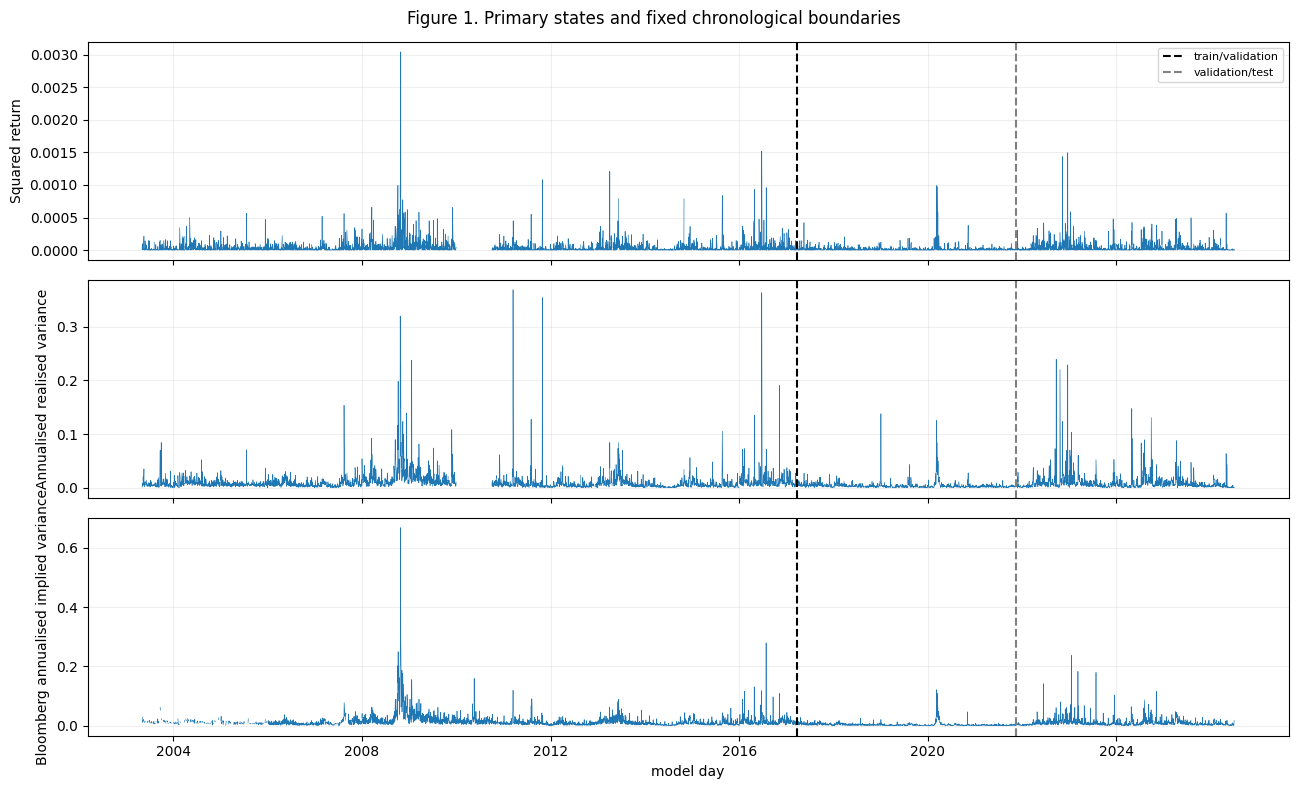

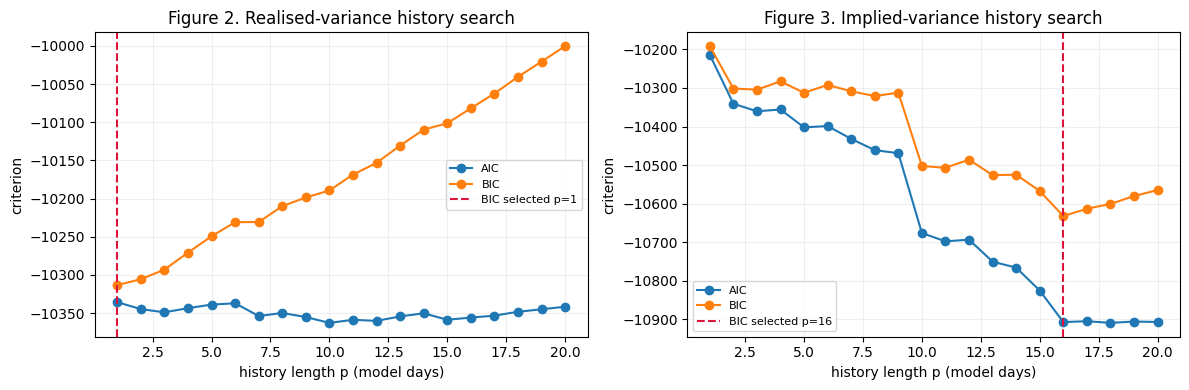

,target,history_order,AIC,BIC,adjusted_R2,n_observations,n_parameters,comparison_sample
0,realised_variance_ann_252,1,-10335.799248,-10313.407656,0.310456,1994,4,common_lag_20_training
1,realised_variance_ann_252,2,-10344.909902,-10305.724616,0.314629,1994,7,common_lag_20_training
2,realised_variance_ann_252,3,-10349.093484,-10293.114505,0.317089,1994,10,common_lag_20_training
3,realised_variance_ann_252,4,-10343.641161,-10270.868487,0.316243,1994,13,common_lag_20_training
4,realised_variance_ann_252,5,-10338.950965,-10249.384598,0.315655,1994,16,common_lag_20_training
5,realised_variance_ann_252,6,-10337.286527,-10230.926466,0.316104,1994,19,common_lag_20_training
6,realised_variance_ann_252,7,-10353.913877,-10230.760123,0.322793,1994,22,common_lag_20_training
7,realised_variance_ann_252,8,-10349.955481,-10210.008032,0.322455,1994,25,common_lag_20_training
8,realised_variance_ann_252,9,-10355.298870,-10198.557727,0.325270,1994,28,common_lag_20_training
9,realised_variance_ann_252,10,-10362.950203,-10189.415366,0.328850,1994,31,common_lag_20_training


Training BIC selected **n*=1** and **m*=16**. Boundary warning: realised=False; implied=False. A warning means the optimum may extend beyond this 20-day horizon; this notebook does not extend the search.

C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_7292\935157210.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gcblocks=pd.DataFrame(gc_rows).groupby("split",group_keys=False).apply(holm).reset_index(drop=True)


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_7292\935157210.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ownblocks=pd.DataFrame(own_rows).groupby("split",group_keys=False).apply(holm).reset_index(drop=True)


## Classical and HAC conditional GC
Classical Holm support remains the selection rule. HAC support is a robust-inference sensitivity for the same restriction block.

...

### Own-history persistence

,split,target,source,history_order,n_observations,comparison_sample,restricted_RSS,unrestricted_RSS,classical_F,raw_p_value,...,unrestricted_AIC,unrestricted_BIC,residual_df,HAC_Wald_stat,HAC_p,HAC_maxlags,edge_id,holm_adjusted_p_value,holm_reject,HAC_support
0,train,realised_variance_ann_252,realised_variance_ann_252,1,3009,selected_order_specific,0.781903,0.778038,14.927407,1.140878e-04,...,-16308.200182,-16284.162730,3005.0,2.132197,1.443384e-01,8,realised_variance_own_history,1.140878e-04,True,False
1,train,implied_variance_ann,implied_variance_ann,16,2128,selected_order_specific,0.751205,0.516471,59.055988,5.724292e-156,...,-11575.776283,-11298.292328,2079.0,16.589555,3.829953e-44,7,implied_variance_own_history,1.144858e-155,True,True
2,validation,realised_variance_ann_252,realised_variance_ann_252,1,1181,selected_order_specific,0.047346,0.046710,16.029360,6.627133e-05,...,-8613.354032,-8593.057565,1177.0,4.123394,4.251860e-02,6,realised_variance_own_history,6.627133e-05,True,True
3,validation,implied_variance_ann,implied_variance_ann,16,1055,selected_order_specific,0.021271,0.017667,12.825582,2.057175e-31,...,-8510.239985,-8267.136478,1006.0,11.572589,5.022140e-28,6,implied_variance_own_history,4.114351e-31,True,True
4,test,realised_variance_ann_252,realised_variance_ann_252,1,1182,selected_order_specific,0.263261,0.262851,1.839332,1.752891e-01,...,-6579.586828,-6559.286975,1178.0,0.617356,4.321896e-01,6,realised_variance_own_history,1.752891e-01,False,False
5,test,implied_variance_ann,implied_variance_ann,16,1031,selected_order_specific,0.214176,0.203141,3.333874,9.754590e-06,...,-5772.783834,-5530.807894,982.0,3.287717,1.267872e-05,6,implied_variance_own_history,1.950918e-05,True,True


### Training residual diagnostics

,target,selected_history_order,lag,Ljung_Box_stat,Ljung_Box_p_value
0,realised_variance_ann_252,1,5,2.116712,0.832771
1,realised_variance_ann_252,1,10,8.236592,0.605739
2,realised_variance_ann_252,1,20,29.886407,0.071715
3,implied_variance_ann,16,5,1.247166,0.940273
4,implied_variance_ann,16,10,8.431006,0.586814
5,implied_variance_ann,16,20,25.556737,0.180955


C:\Users\Rajiv Nawal\AppData\Local\Temp\ipykernel_7292\935157210.py:77: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  individual=pd.DataFrame(lags).groupby("edge_id",group_keys=False).apply(holm).reset_index(drop=True)


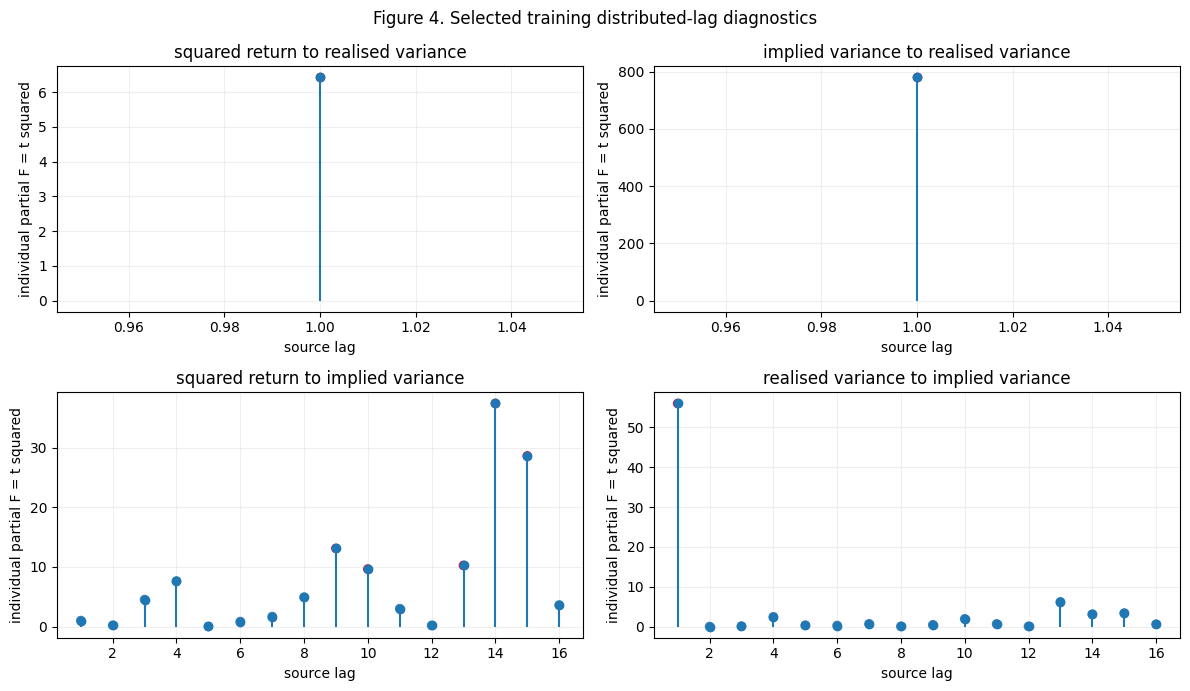

,edge_id,source,target,lag,coefficient,standard_error,t_statistic,partial_F_statistic,raw_p_value,holm_adjusted_p_value,holm_reject
0,squared_return_to_realised_variance,squared_return,realised_variance_ann_252,1,9.023758,3.560974,2.534070,6.421511,1.132501e-02,1.132501e-02,True
1,implied_variance_to_realised_variance,implied_variance_ann,realised_variance_ann_252,1,0.407594,0.014602,27.913467,779.161650,1.168097e-152,1.168097e-152,True
2,squared_return_to_implied_variance,squared_return,implied_variance_ann,1,-4.426174,4.417585,-1.001944,1.003892,3.164871e-01,1.000000e+00,False
3,squared_return_to_implied_variance,squared_return,implied_variance_ann,2,2.079627,4.525471,0.459538,0.211175,6.458957e-01,1.000000e+00,False
4,squared_return_to_implied_variance,squared_return,implied_variance_ann,3,-9.825014,4.617095,-2.127965,4.528233,3.345736e-02,3.011162e-01,False
5,squared_return_to_implied_variance,squared_return,implied_variance_ann,4,12.774946,4.624062,2.762711,7.632571,5.782820e-03,6.361102e-02,False
6,squared_return_to_implied_variance,squared_return,implied_variance_ann,5,0.610912,4.997523,0.122243,0.014943,9.027184e-01,1.000000e+00,False
7,squared_return_to_implied_variance,squared_return,implied_variance_ann,6,-4.560828,4.986923,-0.914558,0.836415,3.605300e-01,1.000000e+00,False
8,squared_return_to_implied_variance,squared_return,implied_variance_ann,7,6.468873,4.998869,1.294067,1.674610,1.957859e-01,1.000000e+00,False
9,squared_return_to_implied_variance,squared_return,implied_variance_ann,8,11.113614,5.008291,2.219043,4.924152,2.659139e-02,2.659139e-01,False


In [2]:

def contiguous_runs(mask):
    runs=[];start=None
    for i,ok in enumerate(np.asarray(mask,bool)):
        if ok and start is None:start=i
        if start is not None and (not ok or i==len(mask)-1):
            end=i if ok and i==len(mask)-1 else i-1;runs.append((start,end,end-start+1));start=None
    return runs

# Variable-specific availability runs on the intact training calendar.
train_idx=np.flatnonzero(panel.sample_split.eq("train"))
station_rows=[];station_blocks=[]
for state in STATES:
    mask=np.isfinite(panel.loc[train_idx,state].to_numpy(float));runs=contiguous_runs(mask);a,b,n=max(runs,key=lambda z:z[2]);long_idx=train_idx[a:b+1]
    for role,(aa,bb,nn) in [("longest", (a,b,n))]+[("substantial",(aa,bb,nn)) for aa,bb,nn in runs if nn>=MIN_STATIONARITY_BLOCK and (aa,bb,nn)!=(a,b,n)]:
        idx=train_idx[aa:bb+1];x=panel.loc[idx,state].to_numpy(float)
        adf_s,adf_p,*_=adfuller(x,regression="c",autolag="AIC")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore");kpss_s,kpss_p,*_=kpss(x,regression="c",nlags="auto")
        if adf_p<ALPHA and kpss_p>=ALPHA:status="stationarity_supported"
        elif adf_p<ALPHA and kpss_p<ALPHA:status="non_unit_root_but_regime_instability"
        elif adf_p>=ALPHA and kpss_p<ALPHA:status="unit_root_concern"
        else:status="mixed"
        rec={"variable":state,"run_role":role,"run_start":panel.loc[idx[0],"model_day"],"run_end":panel.loc[idx[-1],"model_day"],"n_observations":len(idx),"ADF_statistic":adf_s,"ADF_p_value":adf_p,"KPSS_statistic":kpss_s,"KPSS_p_value":kpss_p,"stationarity_interpretation":status}
        station_blocks.append(rec)
        if role=="longest":station_rows.append(rec)
stationarity=pd.DataFrame(station_rows);stationarity_blocks=pd.DataFrame(station_blocks)
stationarity_map=stationarity.set_index("variable").stationarity_interpretation.to_dict()
display(Markdown("## Variable-specific training stationarity\nADF rejection with KPSS rejection is interpreted as non-unit-root behaviour with regime/level instability—not as a simple random walk and not as an instruction to transform the data."))
display(stationarity);display(stationarity_blocks)

fig,axes=plt.subplots(3,1,figsize=(13,8),sharex=True)
for ax,state,label in zip(axes,STATES,["Squared return","Annualised realised variance","Bloomberg annualised implied variance"]):
    ax.plot(panel.model_day,panel[state],lw=.45);ax.axvline(panel.model_day.iloc[train_end],color="black",ls="--",label="train/validation");ax.axvline(panel.model_day.iloc[validation_end],color="grey",ls="--",label="validation/test");ax.set_ylabel(label);ax.grid(alpha=.2)
axes[0].legend(fontsize=8);axes[-1].set_xlabel("model day");fig.suptitle("Figure 1. Primary states and fixed chronological boundaries");fig.tight_layout();plt.show()

order_scan_df=pd.concat([order_scan(panel,"realised_variance_ann_252"),order_scan(panel,"implied_variance_ann")],ignore_index=True)
assert order_scan_df.groupby("target").size().eq(MAX_LAG).all() and order_scan_df.groupby("target").n_observations.nunique().eq(1).all()
n_star=int(order_scan_df.query("target=='realised_variance_ann_252'").sort_values("BIC").iloc[0].history_order)
m_star=int(order_scan_df.query("target=='implied_variance_ann'").sort_values("BIC").iloc[0].history_order)
order_warning={"realised_variance_ann_252":n_star==MAX_LAG,"implied_variance_ann":m_star==MAX_LAG}
fig,axs=plt.subplots(1,2,figsize=(12,4))
for ax,(target,title,selected) in zip(axs,[("realised_variance_ann_252","Figure 2. Realised-variance history search",n_star),("implied_variance_ann","Figure 3. Implied-variance history search",m_star)]):
    d=order_scan_df.query("target==@target");ax.plot(d.history_order,d.AIC,"o-",label="AIC");ax.plot(d.history_order,d.BIC,"o-",label="BIC");ax.axvline(selected,color="crimson",ls="--",label=f"BIC selected p={selected}");ax.set(title=title,xlabel="history length p (model days)",ylabel="criterion");ax.legend(fontsize=8);ax.grid(alpha=.2)
fig.tight_layout();plt.show();display(order_scan_df)
display(Markdown(f"Training BIC selected **n*={n_star}** and **m*={m_star}**. Boundary warning: realised={order_warning['realised_variance_ann_252']}; implied={order_warning['implied_variance_ann']}. A warning means the optimum may extend beyond this 20-day horizon; this notebook does not extend the search."))

edge_specs=[("squared_return_to_realised_variance","squared_return","realised_variance_ann_252",n_star),("implied_variance_to_realised_variance","implied_variance_ann","realised_variance_ann_252",n_star),("squared_return_to_implied_variance","squared_return","implied_variance_ann",m_star),("realised_variance_to_implied_variance","realised_variance_ann_252","implied_variance_ann",m_star)]
gc_rows=[];selected_fit={};selected_names={}
for split in ["train","validation","test"]:
    for edge,source,target,p in edge_specs:
        row,fit,names=gc_test(panel,target,source,p,split);row["edge_id"]=edge;gc_rows.append(row)
        if split=="train":selected_fit[target]=fit;selected_names[target]=names
gcblocks=pd.DataFrame(gc_rows).groupby("split",group_keys=False).apply(holm).reset_index(drop=True)
gcblocks["HAC_support"]=gcblocks.HAC_p<ALPHA
piv=gcblocks.pivot(index="edge_id",columns="split",values="holm_reject")
gcblocks["retained_for_notebook17"]=gcblocks.edge_id.map({e:bool(piv.loc[e,"train"] and piv.loc[e,"validation"]) for e,*_ in edge_specs})

own_rows=[]
for split in ["train","validation","test"]:
    for label,target,p in [("realised_variance_own_history","realised_variance_ann_252",n_star),("implied_variance_own_history","implied_variance_ann",m_star)]:
        row,_,_=gc_test(panel,target,target,p,split);row["edge_id"]=label;own_rows.append(row)
ownblocks=pd.DataFrame(own_rows).groupby("split",group_keys=False).apply(holm).reset_index(drop=True)
ownblocks["HAC_support"]=ownblocks.HAC_p<ALPHA

resid_rows=[]
for target,p in [("realised_variance_ann_252",n_star),("implied_variance_ann",m_star)]:
    fit=selected_fit[target];lb=acorr_ljungbox(fit.resid,lags=[5,10,20],return_df=True)
    for lag,row in lb.iterrows():resid_rows.append({"target":target,"selected_history_order":p,"lag":int(lag),"Ljung_Box_stat":float(row.lb_stat),"Ljung_Box_p_value":float(row.lb_pvalue)})
residuals=pd.DataFrame(resid_rows)
display(Markdown("## Classical and HAC conditional GC\nClassical Holm support remains the selection rule. HAC support is a robust-inference sensitivity for the same restriction block."));display(gcblocks);display(Markdown("### Own-history persistence"));display(ownblocks);display(Markdown("### Training residual diagnostics"));display(residuals)

lags=[]
for edge,source,target,p in edge_specs:
    fit=selected_fit[target];names=selected_names[target];positions=[i for i,n in enumerate(names) if n in lagcols(source,p)]
    for j,pos in enumerate(positions,1):
        lags.append({"edge_id":edge,"source":source,"target":target,"lag":j,"coefficient":float(fit.params[pos]),"standard_error":float(fit.bse[pos]),"t_statistic":float(fit.tvalues[pos]),"partial_F_statistic":float(fit.tvalues[pos]**2),"raw_p_value":float(fit.pvalues[pos])})
individual=pd.DataFrame(lags).groupby("edge_id",group_keys=False).apply(holm).reset_index(drop=True)
fig,axs=plt.subplots(2,2,figsize=(12,7))
for ax,(edge,d) in zip(axs.flat,individual.groupby("edge_id",sort=False)):
    ax.stem(d.lag,d.partial_F_statistic,basefmt=" ");ax.scatter(d.lag,d.partial_F_statistic,c=np.where(d.holm_reject,"crimson","steelblue"));ax.set(title=edge.replace("_"," "),xlabel="source lag",ylabel="individual partial F = t squared");ax.grid(alpha=.2)
fig.suptitle("Figure 4. Selected training distributed-lag diagnostics");fig.tight_layout();plt.show();display(individual)


## 5. Direct four-direction TDMI, binning, and surrogate inference

TDMI selection and inference are now implemented directly for the four source-to-target relationships: squared return → realised variance; implied variance → realised variance; squared return → implied variance; and realised variance → implied variance. Each direction evaluates $I(X_{t-k};Y_t)$ only at positive lags $k=1,\ldots,20$. The target row determines training, validation, or test membership; the source is always at an earlier intact-calendar row. Consequently a validation target may use genuinely preceding end-of-training information, but no target can ever be paired with a future source from a later split.

Mutual information is $I(X;Y)=\sum p(x,y)\log[p(x,y)/(p(x)p(y))]$. It is symmetric, but the explicit source-before-target construction supplies the lead-lag interpretation. A training TDMI peak is the corrected-significant lag with the largest TDMI value; it is a strongest significant lead-lag dependence, not a causal or physical delay.

Both continuous series are quantile-binned. Training-derived edges are frozen—with infinite outer edges—for validation/test. Ten bins and 1,000 circular-shift source surrogates are the primary inferential method. The five/fifteen-bin searches are descriptive timing sensitivities and never alter the ten-bin training selection. Circular shifts preserve source serial structure better than independent shuffling; the one-sided surrogate p-value is $(1+\#\{I^{null}\ge I^{obs}\})/(1+B)$, and Holm correction applies across each direction’s twenty positive lags.

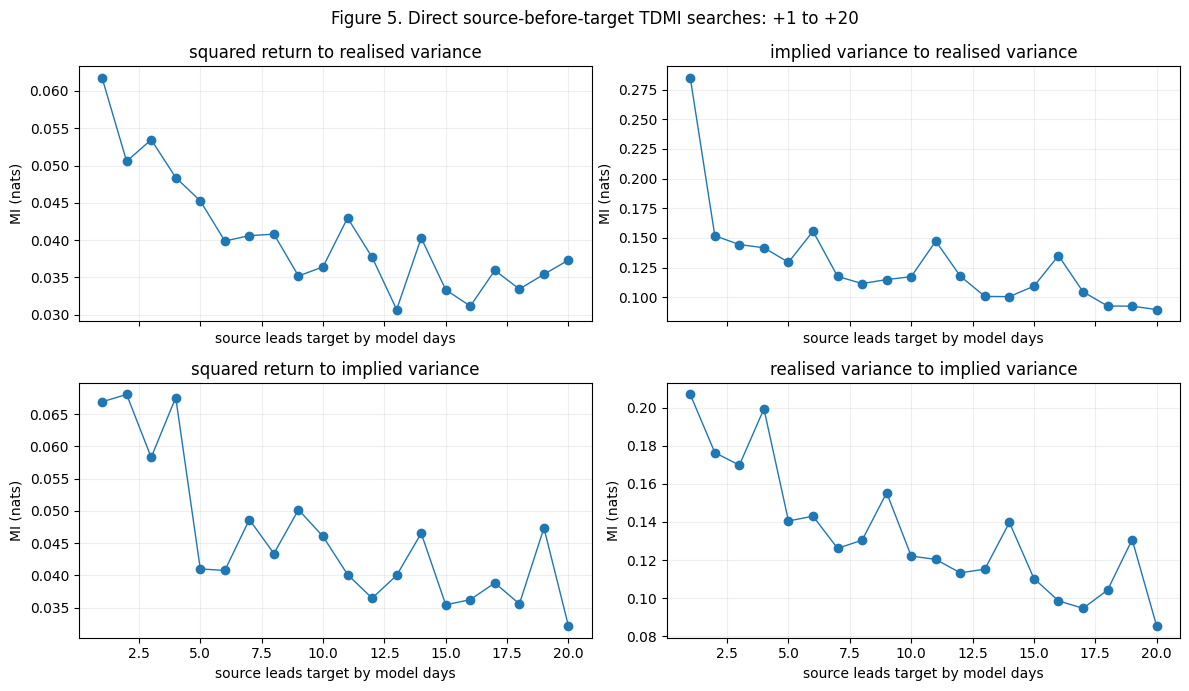

## Direct four-direction TDMI
Directional selection, significance, validation, and test evaluation use only positive source-leading-target lags. No negative-lag inference is used.

,edge_id,source,target,training_tdmi_support,training_tdmi_peak_lag,training_tdmi_value,training_tdmi_raw_p,training_tdmi_holm_p,tdmi_validation_value,tdmi_validation_p,tdmi_validation_support,tdmi_test_value,tdmi_test_p,tdmi_test_support,tdmi_peak_5_bins,tdmi_peak_10_bins,tdmi_peak_15_bins,tdmi_peak_bin_stability
0,squared_return_to_realised_variance,squared_return,realised_variance_ann_252,True,1,0.061755,0.000999,0.01998,0.083556,0.000999,True,0.108486,0.000999,True,1,1,1,stable
1,implied_variance_to_realised_variance,implied_variance_ann,realised_variance_ann_252,True,1,0.284871,0.000999,0.01998,0.234176,0.000999,True,0.294732,0.000999,True,1,1,1,stable
2,squared_return_to_implied_variance,squared_return,implied_variance_ann,True,2,0.068070,0.000999,0.01998,0.085559,0.000999,True,0.073182,0.000999,True,4,2,2,approximately_stable
3,realised_variance_to_implied_variance,realised_variance_ann_252,implied_variance_ann,True,1,0.206841,0.000999,0.01998,0.188724,0.000999,True,0.182921,0.000999,True,1,1,1,stable


In [3]:

def fixed_edges(values,bins):
    x=np.asarray(values,float);x=x[np.isfinite(x)];cuts=np.unique(np.quantile(x,np.linspace(0,1,bins+1)[1:-1]))
    if len(cuts)<1:raise ValueError("TDMI requires at least two distinct training regions.")
    return np.r_[-np.inf,cuts,np.inf]
def mi_value(x,y,ex,ey):
    xb=np.digitize(x,ex[1:-1],right=True);yb=np.digitize(y,ey[1:-1],right=True)
    counts=np.zeros((xb.max()+1,yb.max()+1));np.add.at(counts,(xb,yb),1);joint=counts/counts.sum();prod=joint.sum(1,keepdims=True)@joint.sum(0,keepdims=True);nonzero=joint>0
    return float(np.sum(joint[nonzero]*np.log(joint[nonzero]/prod[nonzero])))
def tdmi_direct(frame,source,target,lag,split,edges,source_override=None):
    # Positive lag only: source at t-k; target row itself defines split membership.
    assert 1<=lag<=MAX_LAG
    base=frame[source].to_numpy(float) if source_override is None else source_override
    source_lagged=np.roll(base,lag);target_current=frame[target].to_numpy(float)
    target_mask=frame.sample_split.eq(split).to_numpy(bool);target_mask[:lag]=False
    valid=target_mask&np.isfinite(source_lagged)&np.isfinite(target_current)
    target_positions=np.flatnonzero(valid);source_positions=target_positions-lag
    assert np.all(source_positions<target_positions)
    assert frame.loc[valid,"sample_split"].eq(split).all()
    if split=="train":assert not frame.loc[valid,"sample_split"].isin(["validation","test"]).any()
    if split=="validation":assert not frame.loc[valid,"sample_split"].eq("test").any()
    return (mi_value(source_lagged[valid],target_current[valid],edges[source],edges[target]),int(valid.sum())) if valid.sum()>=20 else (np.nan,int(valid.sum()))
def surrogate_p(frame,source,target,lag,split,edges,rng,B=TDMI_SURROGATES):
    observed,n=tdmi_direct(frame,source,target,lag,split,edges)
    positions=np.flatnonzero(frame.sample_split.eq(split));base=frame[source].to_numpy(float);segment=base[positions].copy()
    shifts=np.arange(MAX_LAG+1,max(MAX_LAG+2,len(segment)-MAX_LAG))
    null=np.empty(B)
    for i,shift in enumerate(rng.choice(shifts,size=B)):
        altered=base.copy();altered[positions]=np.roll(segment,int(shift))
        null[i]=tdmi_direct(frame,source,target,lag,split,edges,altered)[0]
    return observed,n,float((1+np.sum(null>=observed))/(1+B))
def tdmi_training_search(frame,source,target,bins,with_surrogates):
    edges={source:fixed_edges(frame.loc[frame.sample_split.eq("train")&np.isfinite(frame[source]),source],bins),target:fixed_edges(frame.loc[frame.sample_split.eq("train")&np.isfinite(frame[target]),target],bins)}
    rows=[];rng=np.random.default_rng(RANDOM_SEED+bins+len(source)+len(target))
    for lag in range(1,MAX_LAG+1):
        value,n=tdmi_direct(frame,source,target,lag,"train",edges)
        row={"source":source,"target":target,"split":"train","lag":lag,"bins":bins,"tdmi":value,"n_pairs":n,"raw_p":np.nan}
        if with_surrogates:
            value,n,pv=surrogate_p(frame,source,target,lag,"train",edges,rng);row.update(tdmi=value,n_pairs=n,raw_p=pv)
        rows.append(row)
    out=pd.DataFrame(rows)
    if with_surrogates:
        adjusted=holm(out.rename(columns={"raw_p":"raw_p_value"}))
        out["holm_p"]=adjusted.holm_adjusted_p_value;out["significant"]=adjusted.holm_reject
    else:
        out["holm_p"]=np.nan;out["significant"]=np.nan
    return out,edges

tdmi_specs=[
("squared_return_to_realised_variance","squared_return","realised_variance_ann_252"),
("implied_variance_to_realised_variance","implied_variance_ann","realised_variance_ann_252"),
("squared_return_to_implied_variance","squared_return","implied_variance_ann"),
("realised_variance_to_implied_variance","realised_variance_ann_252","implied_variance_ann")]
primary_curves=[];edge_maps={};primary_summary=[]
for edge,source,target in tdmi_specs:
    curve,edges=tdmi_training_search(panel,source,target,10,True);primary_curves.append(curve.assign(edge_id=edge,curve_role="primary_10_bin"));edge_maps[edge]=edges
    sig=curve[curve.significant.fillna(False)]
    peak=int(sig.sort_values("tdmi",ascending=False).iloc[0].lag) if len(sig) else np.nan
    peak_row=sig.sort_values("tdmi",ascending=False).iloc[0] if len(sig) else None
    primary_summary.append({"edge_id":edge,"source":source,"target":target,"training_tdmi_support":bool(len(sig)),"training_tdmi_peak_lag":peak,"training_tdmi_value":float(peak_row.tdmi) if peak_row is not None else np.nan,"training_tdmi_raw_p":float(peak_row.raw_p) if peak_row is not None else np.nan,"training_tdmi_holm_p":float(peak_row.holm_p) if peak_row is not None else np.nan})
tdmi_curves=pd.concat(primary_curves,ignore_index=True)
assert tdmi_curves.lag.between(1,MAX_LAG).all() and tdmi_curves.groupby("edge_id").size().eq(MAX_LAG).all()

# Training peak is frozen before direct validation/test evaluation; target split remains the membership rule.
tdmi_holdout_rows=[]
for rec in primary_summary:
    if np.isfinite(rec["training_tdmi_peak_lag"]):
        for split in ["validation","test"]:
            value,n,pv=surrogate_p(panel,rec["source"],rec["target"],int(rec["training_tdmi_peak_lag"]),split,edge_maps[rec["edge_id"]],np.random.default_rng(RANDOM_SEED+500+len(rec["edge_id"])))
            tdmi_holdout_rows.append({"edge_id":rec["edge_id"],"split":split,"tdmi_value":value,"tdmi_p":pv,"tdmi_support":pv<ALPHA,"n_pairs":n})
tdmi_holdout=pd.DataFrame(tdmi_holdout_rows)

# Complete direct training peak searches at 5/10/15 bins; 10-bin inference remains primary.
bin_curve_parts=[];bin_peak_rows=[]
for bins in [5,10,15]:
    for edge,source,target in tdmi_specs:
        curve,_=tdmi_training_search(panel,source,target,bins,bins==10)
        bin_curve_parts.append(curve.assign(edge_id=edge,curve_role="bin_sensitivity_descriptive" if bins!=10 else "bin_sensitivity_primary"))
        candidate=curve[curve.significant.fillna(False)] if bins==10 else curve
        peak=int(candidate.sort_values("tdmi",ascending=False).iloc[0].lag) if len(candidate) else np.nan
        bin_peak_rows.append({"edge_id":edge,"bins":bins,"peak_lag":peak,"peak_is_primary_significant":bool(bins==10 and len(candidate))})
bin_peaks=pd.DataFrame(bin_peak_rows)
bin_stability=[]
for edge,d in bin_peaks.groupby("edge_id"):
    vals=d.peak_lag.dropna().to_numpy(float)
    stability="sensitive_to_binning" if len(vals)<2 or np.ptp(vals)>2 else ("stable" if np.ptp(vals)==0 else "approximately_stable")
    bin_stability.append({"edge_id":edge,"tdmi_peak_5_bins":d.loc[d.bins.eq(5),"peak_lag"].iloc[0],"tdmi_peak_10_bins":d.loc[d.bins.eq(10),"peak_lag"].iloc[0],"tdmi_peak_15_bins":d.loc[d.bins.eq(15),"peak_lag"].iloc[0],"tdmi_peak_bin_stability":stability})
bin_stability=pd.DataFrame(bin_stability)

summary_base=pd.DataFrame(primary_summary)
for split in ["validation","test"]:
    d=tdmi_holdout[tdmi_holdout.split.eq(split)].set_index("edge_id") if len(tdmi_holdout) else pd.DataFrame()
    summary_base[f"tdmi_{split}_value"]=summary_base.edge_id.map(d.tdmi_value if len(d) else {})
    summary_base[f"tdmi_{split}_p"]=summary_base.edge_id.map(d.tdmi_p if len(d) else {})
    summary_base[f"tdmi_{split}_support"]=summary_base.edge_id.map(d.tdmi_support if len(d) else {}).fillna(False).astype(bool)
tdmi_summary=summary_base.merge(bin_stability,on="edge_id",how="left")

fig,axs=plt.subplots(2,2,figsize=(12,7),sharex=True)
for ax,(edge,d) in zip(axs.flat,tdmi_curves.groupby("edge_id",sort=False)):
    ax.plot(d.lag,d.tdmi,"o-",lw=1);ax.set(title=edge.replace("_"," "),xlabel="source leads target by model days",ylabel="MI (nats)");ax.grid(alpha=.2)
fig.suptitle("Figure 5. Direct source-before-target TDMI searches: +1 to +20");fig.tight_layout();plt.show()
display(Markdown("## Direct four-direction TDMI\nDirectional selection, significance, validation, and test evaluation use only positive source-leading-target lags. No negative-lag inference is used."));display(tdmi_summary)


## 6. Evidence hierarchy and frozen hand-off

The retained-driver rule is unchanged: classical conditional GC must survive Holm correction in both training and validation. Test does not revise that decision. The final hand-off table separates selection from robust inference, TDMI agreement, and final-holdout persistence. A statistically significant relationship can still have small partial R²; the final interpretation therefore considers p-values, effect size, validation, test, HAC robustness, TDMI, and bin stability together.

The closure-gap realised-variance state is a genuine robustness check. It includes available reopening movement through 252 times rv_with_closure_gap but is not allowed to select a new order or TDMI peak.

# From Linus's general model to the frozen empirical specification

Linus's realised-variance background is written as

$$
\widetilde{\sigma}_i^2
=
\widetilde{\phi}_i+
\sum_{j=1}^{n}\left(
\widetilde{\alpha}_j r_{i-j}^2+
\widetilde{\beta}_j\widetilde{\sigma}_{i-j}^2+
\widetilde{\gamma}_j\sigma_{i\mid i-j}^2
\right)
+\widetilde{\nu}_i\eta_i,
$$

while the implied-variance background is

$$
\sigma_i^2
=
\phi_i+
\sum_{j=1}^{m}\left(
\alpha_j r_{i-j}^2+
\beta_j\widetilde{\sigma}_{i-j}^2+
\gamma_j\sigma_{i\mid i-j}^2
\right)
+\nu_i\zeta_i.
$$

The stochastic terms are therefore the complete products
$\widetilde{\nu}_i\eta_i$ and $\nu_i\zeta_i$, not bare $\eta_i$, bare $\zeta_i$, or a generic epsilon. Here $\eta_i$ and $\zeta_i$ are innovations/shocks, while $\widetilde{\nu}_i$ and $\nu_i$ scale those shocks. Linus permits those scales to be constant or time varying. This notation is deliberately distinct from Equation (1)'s spot-return shock, $r_i=\mu_i+\widetilde{\sigma}_i\epsilon_i$. Linus writes the baseline terms as $\widetilde{\phi}_i$ and $\phi_i$, allowing possible time variation. Exercise 1 does not model a separate time-varying intercept process: the conditional GC regressions use a constant intercept within each estimation sample while identifying historical predictor structure and lag order.

For the empirical regression, define the composite disturbances

$$
u_t^R\equiv\widetilde{\nu}_t\eta_t,
\qquad
u_t^I\equiv\nu_t\zeta_t.
$$

OLS observes only the realised composite residual $u_t^R$ or $u_t^I$ in a fitted equation $Y_t=X_t\beta+u_t$. It does not separately observe an innovation scale and an innovation: one residual cannot identify both components without additional distributional and scale-evolution assumptions. Within the assumed empirical specification, $u_t^R$ and $u_t^I$ correspond to Linus's composite innovation terms. In observed data, however, fitted residuals may also absorb measurement error, omitted dynamics, model misspecification, and shocks not explicitly represented by the simplified background equation. These equalities describe the model representation, not separate empirical identification of an innovation scale and a standardised shock. Thus Notebook 16 identifies conditional-history structure while the product remains in the regression residual. For example, if a scale were constant and $\zeta_t\sim N(0,\Delta t)$, then $\operatorname{Var}(u_t^I)=\nu^2\Delta t$; similarly $\operatorname{Var}(u_t^R)=\widetilde{\nu}^{\,2}\Delta t$. Notebook 16 does not perform that decomposition or introduce a stochastic-volatility model. HAC/Newey–West similarly does not estimate $\nu_t$: it only checks coefficient-block inference against heteroskedasticity and short-range residual autocorrelation.

Write the three observed empirical states as

$$
Q_t\equiv r_t^2=(\text{within_session_log_return}_t)^2,\qquad
R_t\equiv252\,\text{rv_within}_t,\qquad
I_t\equiv\text{iv_ann_var}_t=\left(\frac{q_t}{100}\right)^2.
$$

They are, respectively, squared complete-session return, annualised realised variance under the 252-model-day convention, and Bloomberg annualised overnight/1D ATM implied variance. Because $R_t$ is an empirically annualised representation of realised variance, its coefficients and innovation scale are parameters of that chosen representation. They are not numerically identical copies of generic parameters under every possible time-unit convention. The same unit qualification applies wherever the numerical magnitude of a parameter depends on the chosen units of $R_t$ or $I_t$: structural roles are preserved while numerical scale reflects the empirical model. Equation (5) is not implemented. Consequently, observed $I_{t-j}$ is an empirical observable substitute for the unavailable conditional forward-implied-variance object $\sigma_{t\mid t-j}^2$; it is not claimed to be mathematically identical to it.

Under this approved simplification, Linus's candidate system becomes

$$
R_t=
\widetilde{\phi}+
\sum_{j=1}^{n}
\left[
\widetilde{\alpha}_jQ_{t-j}+
\widetilde{\beta}_jR_{t-j}+
\widetilde{\gamma}_jI_{t-j}
\right]+u_t^R,
\qquad
u_t^R=\widetilde{\nu}_t\eta_t,
$$

and

$$
I_t=
\phi+
\sum_{j=1}^{m}
\left[
\alpha_jQ_{t-j}+
\beta_jR_{t-j}+
\gamma_jI_{t-j}
\right]+u_t^I,
\qquad
u_t^I=\nu_t\zeta_t.
$$

“Construct the causal structure” is used narrowly here. Notebook 16 does not discover an unrestricted structural causal graph or prove interventionist causality. Within Linus's two candidate variance background equations, it tests whether the historical blocks $Q\rightarrow R$, $I\rightarrow R$, $Q\rightarrow I$, and $R\rightarrow I$ contain supported predictive/dependence information; own-history persistence is assessed separately. It does not create a third distributed-lag equation with $Q_t$ as target, because Linus's return equation has a different role.

Conditional Granger causality determines whether an entire source-history block adds incremental **linear predictive information** after the other histories in the relevant target equation are controlled for. For example, $I\rightarrow R$ tests whether $I_{t-1},\ldots,I_{t-n}$ jointly improve prediction of $R_t$ beyond the $R$ and $Q$ histories. Conditional GC is therefore the criterion for retaining the corresponding coefficient block in the parametric background. TDMI is complementary pairwise nonlinear lead-lag evidence, evaluating $I(X_{t-k};Y_t)$ for $k=1,\ldots,20$. The direct implementation tests both directions explicitly: $I(I_{t-k};R_t)$ for implied variance leading realised variance and $I(R_{t-k};I_t)$ for the reverse relationship. This is bidirectional detection using only positive lag numbers because source and target are explicitly reversed; it keeps the target index visible and prevents split-boundary leakage.

Linus leaves the history orders $n$ and $m$ generic. Training-only BIC searches $p=1,\ldots,20$ separately for the two equations; AIC is secondary. The executed result is

$$
\boxed{n^*=1,\qquad m^*=16.}
$$

These are history lengths, not causal delays. Conditional on the three candidate histories, realised variance requires only one model day of history by BIC, whereas implied variance has substantially longer selected persistence of sixteen model days.

The predefined classical training-plus-validation GC rule retains all four candidate cross-variable blocks. This is a substantive selection result: the exercise tested whether any candidate class should be removed and found that none should be removed under that rule, while fixing target-specific history orders. The evidence is not equally strong. Implied variance $\rightarrow$ realised variance is the strongest and most stable relationship; the other retained blocks are less robust across HAC inference and/or the untouched holdout. TDMI records complementary timing evidence but does not override the parametric GC retention rule.

The frozen structure passed to Notebook 17 is therefore

$$
\boxed{
R_t=
\widetilde{\phi}+
\widetilde{\alpha}_1Q_{t-1}+
\widetilde{\beta}_1R_{t-1}+
\widetilde{\gamma}_1I_{t-1}
+u_t^R,
\qquad
u_t^R=\widetilde{\nu}_t\eta_t.
}
$$

Today's annualised realised variance has one model day of squared-return, realised-variance, and implied-variance history, plus the unresolved composite realised-variance innovation. It is not a claim that Notebook 16 has calibrated $\widetilde{\alpha}_1$, $\widetilde{\beta}_1$, or $\widetilde{\gamma}_1$ as final forecasting coefficients.

The corresponding implied-variance structure is

$$
\boxed{
I_t=
\phi+
\sum_{j=1}^{16}
\left[
\alpha_jQ_{t-j}+
\beta_jR_{t-j}+
\gamma_jI_{t-j}
\right]
+u_t^I,
\qquad
u_t^I=\nu_t\zeta_t.
}
$$

Today's annualised implied variance consequently uses sixteen model days of each candidate history plus Linus's composite implied-variance innovation.

Linus's generic model therefore had unspecified $n,m$ and candidate blocks present in principle. After Notebook 16, $n=1$, $m=16$, all four cross-variable blocks survive the primary rule, and the observed overnight/1D implied state replaces—not equals—the exact Equation (5) forward object. The result is a frozen empirical background **structure** ready for Notebook 17's coefficient calibration and out-of-sample evaluation.

Notebook 16 has not estimated event weights, constructed eventless counterfactuals, calibrated the final forecasting backgrounds, proved structural causality, separately identified $\widetilde{\nu}_t$ and $\eta_t$ or $\nu_t$ and $\zeta_t$, implemented Equation (5), introduced scheduled-event predictors, or estimated event-driven multiplicative weights. It operationalises dependence-structure and history-order selection. The unexplained innovations remain the composite residual terms $u_t^R=\widetilde{\nu}_t\eta_t$ and $u_t^I=\nu_t\zeta_t$.

In [4]:

closure_states=["squared_return","realised_variance_with_closure_ann_252","implied_variance_ann"];panel["_closure_eligible"]=panel.structure_eligible&np.isfinite(panel.realised_variance_with_closure_ann_252)
closure_specs=[("squared_return_to_realised_variance","squared_return","realised_variance_with_closure_ann_252",n_star),("implied_variance_to_realised_variance","implied_variance_ann","realised_variance_with_closure_ann_252",n_star),("squared_return_to_implied_variance","squared_return","implied_variance_ann",m_star),("realised_variance_to_implied_variance","realised_variance_with_closure_ann_252","implied_variance_ann",m_star)]
cg=[]
for edge,source,target,p in closure_specs:
    r,_,_=gc_test(panel,target,source,p,"train",closure_states);r["edge_id"]=edge;cg.append(r)
closure_gc=holm(pd.DataFrame(cg));closure_gc["HAC_support"]=closure_gc.HAC_p<ALPHA
primary_train=gcblocks.query("split=='train'")[["edge_id","holm_reject"]].rename(columns={"holm_reject":"primary_classical_support"})
closure_gc=closure_gc.merge(primary_train,on="edge_id");closure_gc["closure_gap_training_robust"]=closure_gc.holm_reject.eq(closure_gc.primary_classical_support)

# System qualification includes every state entering each conditional regression.
def sysq(statuses):
    vals=set(statuses.values())
    if vals=={"stationarity_supported"}:return "stationarity_supported_across_system"
    if "unit_root_concern" in vals:return "unit_root_concern_present"
    if "non_unit_root_but_regime_instability" in vals and vals.issubset({"stationarity_supported","non_unit_root_but_regime_instability"}):return "no_clear_unit_root_but_regime_instability_present"
    return "mixed_stationarity_evidence"
system_stationarity_qualification=sysq(stationarity_map)
def gr(edge,split):return gcblocks[(gcblocks.edge_id==edge)&(gcblocks.split==split)].iloc[0]

spec=[]
for edge,source,target,p in edge_specs:
    tr,va,te=gr(edge,"train"),gr(edge,"validation"),gr(edge,"test");td=tdmi_summary[tdmi_summary.edge_id==edge].iloc[0];cl=closure_gc[closure_gc.edge_id==edge].iloc[0]
    retained=bool(tr.holm_reject and va.holm_reject);testok=bool(te.holm_reject);hac_tv=bool(tr.HAC_support and va.HAC_support)
    evidence="not_retained" if not retained else ("retained_but_not_holdout_stable" if not testok else ("classical_only_or_robustness_sensitive" if not hac_tv else ("very_strong_and_stable" if td.training_tdmi_support else "retained_with_no_TDMI_peak")))
    spec.append({"source":source,"target":target,"selected_target_history_order":p,"retained_from_train_validation":retained,"train_classical_support":bool(tr.holm_reject),"train_classical_raw_p":tr.raw_p_value,"train_classical_holm_p":tr.holm_adjusted_p_value,"train_partial_R2":tr.partial_R2,"validation_classical_support":bool(va.holm_reject),"validation_classical_raw_p":va.raw_p_value,"validation_classical_holm_p":va.holm_adjusted_p_value,"validation_partial_R2":va.partial_R2,"test_classical_support":testok,"test_classical_raw_p":te.raw_p_value,"test_classical_holm_p":te.holm_adjusted_p_value,"test_partial_R2":te.partial_R2,"hac_support_train":bool(tr.HAC_support),"hac_support_validation":bool(va.HAC_support),"hac_support_test":bool(te.HAC_support),"train_validation_hac_robust":hac_tv,"holdout_stable":testok,"holdout_hac_robust":bool(testok and te.HAC_support),"training_tdmi_peak_lag":td.training_tdmi_peak_lag,"training_tdmi_value":td.training_tdmi_value,"training_tdmi_raw_p":td.training_tdmi_raw_p,"training_tdmi_holm_p":td.training_tdmi_holm_p,"tdmi_training_support":bool(td.training_tdmi_support),"tdmi_validation_value":td.tdmi_validation_value,"tdmi_validation_p":td.tdmi_validation_p,"tdmi_validation_support":bool(td.tdmi_validation_support),"tdmi_test_value":td.tdmi_test_value,"tdmi_test_p":td.tdmi_test_p,"tdmi_test_support":bool(td.tdmi_test_support),"tdmi_peak_5_bins":td.tdmi_peak_5_bins,"tdmi_peak_10_bins":td.tdmi_peak_10_bins,"tdmi_peak_15_bins":td.tdmi_peak_15_bins,"tdmi_peak_bin_stability":td.tdmi_peak_bin_stability,"source_stationarity_interpretation":stationarity_map[source],"target_stationarity_interpretation":stationarity_map[target],"system_stationarity_qualification":system_stationarity_qualification,"closure_gap_training_robust":bool(cl.closure_gap_training_robust),"history_order_boundary_warning":order_warning[target],"equation5_used":False,"evidence_strength":evidence})
model_spec=pd.DataFrame(spec)

trows=[]
for target,p in [("realised_variance_ann_252",n_star),("implied_variance_ann",m_star)]:
    z=order_scan_df[(order_scan_df.target==target)&(order_scan_df.history_order==p)].iloc[0];own=ownblocks[(ownblocks.target==target)&(ownblocks.split=="train")].iloc[0];lb=residuals[residuals.target==target].set_index("lag").Ljung_Box_p_value
    trows.append({"target":target,"selected_history_order":p,"AIC":z.AIC,"BIC":z.BIC,"order_boundary_warning":order_warning[target],"own_history_classical_support_train":bool(own.holm_reject),"own_history_HAC_support_train":bool(own.HAC_support),"residual_LB5_p":lb.get(5,np.nan),"residual_LB10_p":lb.get(10,np.nan),"residual_LB20_p":lb.get(20,np.nan)})
target_summary=pd.DataFrame(trows)
# Target-equation sample sizes are explicit; both source-block tests share a target/order sample.
selected_sample_counts=(gcblocks[gcblocks.test_type.eq("cross_variable") if "test_type" in gcblocks.columns else gcblocks.edge_id.notna()]
    .groupby(["target","split"],as_index=False)["n_observations"].first()
    .pivot(index="target",columns="split",values="n_observations").reset_index()
    .rename(columns={"train":"selected_n_train","validation":"selected_n_validation","test":"selected_n_test"}))
target_summary=target_summary.merge(selected_sample_counts,on="target",how="left")
sensitivity=pd.concat([bin_stability.assign(sensitivity="TDMI_bin_peak"),closure_gc[["edge_id","closure_gap_training_robust"]].assign(sensitivity="closure_gap_training"),model_spec[["source","target","train_validation_hac_robust","holdout_hac_robust"]].assign(sensitivity="HAC_inference")],ignore_index=True,sort=False)
all_curves=pd.concat([tdmi_curves,*bin_curve_parts],ignore_index=True,sort=False)
exports={"16_empirical_analysis_panel.csv":panel[["model_day","sample_split","structure_eligible"]+STATES+["realised_variance_with_closure_ann_252"]],"16_stationarity_diagnostics.csv":stationarity_blocks,"16_gc_order_scan.csv":order_scan_df,"16_gc_block_tests.csv":pd.concat([gcblocks.assign(test_type="cross_variable"),ownblocks.assign(test_type="own_history")],ignore_index=True),"16_gc_individual_lag_diagnostics.csv":individual,"16_residual_diagnostics.csv":residuals,"16_tdmi_curves.csv":all_curves,"16_tdmi_summary.csv":tdmi_summary,"16_closure_gap_sensitivity.csv":closure_gc,"16_model_specification.csv":model_spec,"16_target_model_summary.csv":target_summary,"16_sensitivity_summary.csv":sensitivity}
for name,frame in exports.items():
    frame=frame.copy();frame.insert(0,"RUN_ID",RUN_ID);exports[name]=frame;frame.to_csv(PROCESSED_DIR/name,index=False)
ids=[]
for name,frame in exports.items():
    load=pd.read_csv(PROCESSED_DIR/name);assert len(load)==len(frame) and load.RUN_ID.nunique()==1 and load.RUN_ID.iloc[0]==RUN_ID;ids.append(load.RUN_ID.iloc[0])
assert len(set(ids))==1 and MAX_LAG==20 and TDMI_SURROGATES>=1000 and tdmi_curves.lag.between(1,20).all() and not model_spec.equation5_used.any()
assert all(model_spec.retained_from_train_validation.eq(model_spec.train_classical_support&model_spec.validation_classical_support))
display(Markdown("## Evidence-aware frozen hand-off"));display(model_spec);display(target_summary);display(closure_gc)
retained=model_spec.loc[model_spec.retained_from_train_validation,"source"].str.cat(model_spec.loc[model_spec.retained_from_train_validation,"target"],sep=" -> ").tolist()
failed=model_spec.loc[model_spec.retained_from_train_validation&~model_spec.holdout_stable,"source"].str.cat(model_spec.loc[model_spec.retained_from_train_validation&~model_spec.holdout_stable,"target"],sep=" -> ").tolist()
display(Markdown(f"""# What Notebook 16 has established

RUN_ID: {RUN_ID}. BIC selected n*={n_star}, m*={m_star}; boundary warnings={order_warning}. System stationarity qualification: {system_stationarity_qualification}. Primary train-plus-validation GC relationships: {", ".join(retained) or "none"}. Those selected but not classical-holdout stable: {", ".join(failed) or "none"}; this is evidence of temporal/regime dependence, not retrospective removal.

All TDMI direction selection uses direct positive source-leading-target lags. Training peaks, frozen validation/test evidence, and 5/10/15-bin timing stability are recorded separately. Closure-gap robustness is explicitly a **training-stage frozen-specification** check. Equation (5), event terms, hidden-event signals, and forecasting remain outside scope."""))
import inspect
assert "structure_eligible" not in inspect.getsource(gc_valid_rows)
assert order_scan_df.groupby("target").n_observations.nunique().eq(1).all()
assert (target_summary.selected_n_train >= order_scan_df.groupby("target").n_observations.first().reindex(target_summary.target).to_numpy()).all()
freeze_checks={
    "Fresh kernel run":"PASS",
    "Single RUN_ID across outputs":"PASS" if len(set(ids))==1 else "FAIL",
    "GC uses target-specific samples":"PASS",
    "Order scan uses common lag-20 target-specific sample":"PASS",
    "Selected-order GC refitted on maximal valid sample":"PASS",
    "TDMI direct-direction logic unchanged":"PASS",
    "Equation (5) unused":"PASS" if not model_spec.equation5_used.any() else "FAIL",
    "No event predictors used":"PASS",
    "Notebook 14 unchanged":"PASS (frozen; not modified by this notebook)",
    "Notebook 15 unchanged":"PASS (frozen; not modified by this notebook)"}
freeze_table=pd.DataFrame(freeze_checks.items(),columns=["freeze_check","status"]);display(Markdown("# Notebook 16 freeze check"));display(freeze_table)
assert all(str(v).startswith("PASS") for v in freeze_checks.values())
print("NOTEBOOK 16 FINAL FREEZE CANDIDATE: PASS")



## Evidence-aware frozen hand-off

,source,target,selected_target_history_order,retained_from_train_validation,train_classical_support,train_classical_raw_p,train_classical_holm_p,train_partial_R2,validation_classical_support,validation_classical_raw_p,...,tdmi_peak_10_bins,tdmi_peak_15_bins,tdmi_peak_bin_stability,source_stationarity_interpretation,target_stationarity_interpretation,system_stationarity_qualification,closure_gap_training_robust,history_order_boundary_warning,equation5_used,evidence_strength
0,squared_return,realised_variance_ann_252,1,True,True,1.132501e-02,1.132501e-02,0.002132,True,1.707928e-03,...,1,1,stable,mixed,stationarity_supported,mixed_stationarity_evidence,True,False,False,retained_but_not_holdout_stable
1,implied_variance_ann,realised_variance_ann_252,1,True,True,1.168097e-152,4.672388e-152,0.205901,True,2.674205e-39,...,1,1,stable,non_unit_root_but_regime_instability,stationarity_supported,mixed_stationarity_evidence,True,False,False,very_strong_and_stable
2,squared_return,implied_variance_ann,16,True,True,1.068401e-18,3.205204e-18,0.057573,True,2.742747e-08,...,2,2,approximately_stable,mixed,non_unit_root_but_regime_instability,mixed_stationarity_evidence,True,False,False,retained_but_not_holdout_stable
3,realised_variance_ann_252,implied_variance_ann,16,True,True,2.566996e-10,5.133992e-10,0.037143,True,5.153600e-05,...,1,1,stable,stationarity_supported,non_unit_root_but_regime_instability,mixed_stationarity_evidence,True,False,False,retained_but_not_holdout_stable


,target,selected_history_order,AIC,BIC,order_boundary_warning,own_history_classical_support_train,own_history_HAC_support_train,residual_LB5_p,residual_LB10_p,residual_LB20_p,selected_n_test,selected_n_train,selected_n_validation
0,realised_variance_ann_252,1,-10335.799248,-10313.407656,False,True,False,0.832771,0.605739,0.071715,1182,3009,1181
1,implied_variance_ann,16,-10906.966862,-10632.156513,False,True,True,0.940273,0.586814,0.180955,1031,2128,1055


,split,target,source,history_order,n_observations,comparison_sample,restricted_RSS,unrestricted_RSS,classical_F,raw_p_value,...,residual_df,HAC_Wald_stat,HAC_p,HAC_maxlags,edge_id,holm_adjusted_p_value,holm_reject,HAC_support,primary_classical_support,closure_gap_training_robust
0,train,realised_variance_with_closure_ann_252,squared_return,1,3006,selected_order_specific,0.798600,0.796793,6.809444,9.112723e-03,...,3002.0,2.674091,1.020984e-01,8,squared_return_to_realised_variance,9.112723e-03,True,False,True,True
1,train,realised_variance_with_closure_ann_252,implied_variance_ann,1,3006,selected_order_specific,0.991985,0.796793,735.405639,4.798986e-145,...,3002.0,70.843317,5.904360e-17,8,implied_variance_to_realised_variance,1.919594e-144,True,True,True,True
2,train,implied_variance_ann,squared_return,16,2127,selected_order_specific,0.547181,0.516270,7.776035,3.172573e-18,...,2078.0,0.923530,5.412696e-01,7,squared_return_to_implied_variance,9.517719e-18,True,False,True,True
3,train,implied_variance_ann,realised_variance_with_closure_ann_252,16,2127,selected_order_specific,0.536378,0.516270,5.058474,1.911593e-10,...,2078.0,0.567038,9.099422e-01,7,realised_variance_to_implied_variance,3.823187e-10,True,False,True,True


# What Notebook 16 has established

RUN_ID: 2026-08-10T22:55:43.383518+00:00. BIC selected n*=1, m*=16; boundary warnings={'realised_variance_ann_252': False, 'implied_variance_ann': False}. System stationarity qualification: mixed_stationarity_evidence. Primary train-plus-validation GC relationships: squared_return -> realised_variance_ann_252, implied_variance_ann -> realised_variance_ann_252, squared_return -> implied_variance_ann, realised_variance_ann_252 -> implied_variance_ann. Those selected but not classical-holdout stable: squared_return -> realised_variance_ann_252, squared_return -> implied_variance_ann, realised_variance_ann_252 -> implied_variance_ann; this is evidence of temporal/regime dependence, not retrospective removal.

All TDMI direction selection uses direct positive source-leading-target lags. Training peaks, frozen validation/test evidence, and 5/10/15-bin timing stability are recorded separately. Closure-gap robustness is explicitly a **training-stage frozen-specification** check. Equation (5), event terms, hidden-event signals, and forecasting remain outside scope.

# Notebook 16 freeze check

,freeze_check,status
0,Fresh kernel run,PASS
1,Single RUN_ID across outputs,PASS
2,GC uses target-specific samples,PASS
3,Order scan uses common lag-20 target-specific ...,PASS
4,Selected-order GC refitted on maximal valid sa...,PASS
5,TDMI direct-direction logic unchanged,PASS
6,Equation (5) unused,PASS
7,No event predictors used,PASS
8,Notebook 14 unchanged,PASS (frozen; not modified by this notebook)
9,Notebook 15 unchanged,PASS (frozen; not modified by this notebook)


NOTEBOOK 16 FINAL FREEZE CANDIDATE: PASS


## 7. Final limitations

This notebook is an empirical dependence audit and specification hand-off. It does not prove structural causality, establish a true physical lag, estimate an event weight, identify hidden events, or establish forecast improvement. Regime changes or structural breaks may matter even where ADF rejects a unit root; the evidence-strength fields make that qualification visible. Notebook 17 is not edited here.